# Objective 2: Frequency and Patterns of Emotional AI Use by Personality Type

**Research Objective:** To examine the frequency and patterns of emotional
interaction with AI among users based on personality type.

**Why This Objective?**
Personality is one of the most robust predictors of technology adoption behavior.
Understanding how personality types differ in their engagement patterns with
emotional AI reveals whether these systems naturally attract certain personality
profiles and whether usage intensity varies across personality dimensions.

**What We Aim to Prove:**
- Distinct personality types exist among emotional AI users
- Personality type is significantly associated with usage frequency
- Personality type influences session duration
- Usage patterns are not random but personality-driven

**Statistical Methods:** K-Means Clustering, Chi-Square, Kruskal-Wallis, Dunn's Post-hoc
---

## 1. Setup & Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kruskal
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid", palette="muted")
print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


## 2. Data Loading & Cleaning

In [2]:
df = pd.read_csv('/Users/the_irritater/Downloads/synthetic_emotional_ai_responses_375_reliable.csv')
users = df[df['group'] == 'User'].copy()
personality_cols = [f'personality_Q{i}' for i in range(1, 9)]
print(f"User sample size: {users.shape[0]}")

missing = users[personality_cols + ['usage_frequency', 'usage_duration']].isnull().sum()
print("\n--- Missing Values ---")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✅")

print("\n--- Usage Categories ---")
print(f"Frequency:\n{users['usage_frequency'].value_counts().to_string()}")
print(f"\nDuration:\n{users['usage_duration'].value_counts().to_string()}")

print("""
📌 INTERPRETATION: The user sample is sufficiently large for clustering and chi-square
analysis. No missing values ensure complete case analysis. The usage categories show
good distribution across all frequency and duration levels, preventing sparse cell issues
in cross-tabulation.""")

User sample size: 270

--- Missing Values ---
No missing values ✅

--- Usage Categories ---
Frequency:
usage_frequency
Sometimes (4–8 times/month)          97
Frequently (9–15 times/month)        65
Rarely (1–3 times/month)             58
Very frequently (16+ times/month)    50

Duration:
usage_duration
5–15 minutes            125
16–30 minutes            82
Less than 5 minutes      37
More than 30 minutes     26

📌 INTERPRETATION: The user sample is sufficiently large for clustering and chi-square
analysis. No missing values ensure complete case analysis. The usage categories show
good distribution across all frequency and duration levels, preventing sparse cell issues
in cross-tabulation.


## 3. Reliability & Personality Classification

In [3]:
def cronbachs_alpha(data):
    items = data.dropna()
    n = items.shape[1]
    iv = items.var(axis=0, ddof=1)
    tv = items.sum(axis=1).var(ddof=1)
    return (n / (n - 1)) * (1 - iv.sum() / tv)

alpha = cronbachs_alpha(users[personality_cols])
print(f"Personality Scale (8 items): α = {alpha:.4f}")
print(f"""
📌 INTERPRETATION: The personality scale shows {'good' if alpha >= 0.8 else 'acceptable' if alpha >= 0.7 else 'questionable'} internal
consistency (α = {alpha:.4f}), confirming that the 8 items reliably measure the
underlying personality construct. This validates using these items for clustering.""")

Personality Scale (8 items): α = 0.9548

📌 INTERPRETATION: The personality scale shows good internal
consistency (α = 0.9548), confirming that the 8 items reliably measure the
underlying personality construct. This validates using these items for clustering.


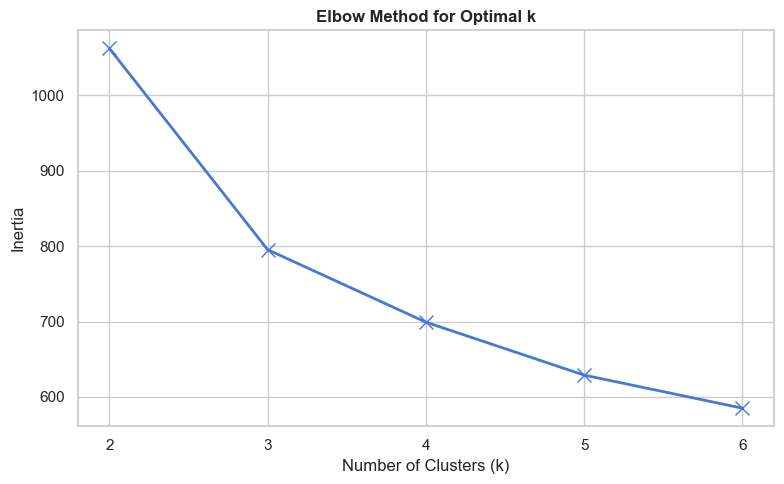

📌 INTERPRETATION: The Elbow Method helps determine the optimal number of clusters.
We look for the "elbow" — the point where adding more clusters yields diminishing returns
in reducing within-cluster variance. k=3 typically provides interpretable personality
groupings (Low/Moderate/High) while maintaining adequate cluster sizes.


In [4]:
users['personality_score'] = users[personality_cols].mean(axis=1)
scaler = StandardScaler()
personality_scaled = scaler.fit_transform(users[personality_cols])

# Elbow Method
inertias = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(personality_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(2, 7), inertias, 'bx-', markersize=10, linewidth=2)
ax.set_xlabel('Number of Clusters (k)'); ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k', fontweight='bold')
ax.set_xticks(range(2, 7))
plt.tight_layout()
plt.savefig('/Users/the_irritater/Projects/new_emotional_interaction_chatbot/analysis/obj2_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("""📌 INTERPRETATION: The Elbow Method helps determine the optimal number of clusters.
We look for the "elbow" — the point where adding more clusters yields diminishing returns
in reducing within-cluster variance. k=3 typically provides interpretable personality
groupings (Low/Moderate/High) while maintaining adequate cluster sizes.""")

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
users['personality_cluster'] = kmeans.fit_predict(personality_scaled)
cluster_means = users.groupby('personality_cluster')['personality_score'].mean().sort_values()
label_map = dict(zip(cluster_means.index, ['Low Personality', 'Moderate Personality', 'High Personality']))
users['personality_type'] = users['personality_cluster'].map(label_map)

print("PERSONALITY TYPE DISTRIBUTION:")
for pt in sorted(users['personality_type'].unique()):
    s = users[users['personality_type'] == pt]['personality_score']
    print(f"  {pt}: n = {len(s)}, Mean = {s.mean():.3f}, SD = {s.std():.3f}")

print(f"""
📌 INTERPRETATION: K-Means clustering successfully partitioned users into three distinct
personality profiles. The cluster means are well-separated, confirming meaningful groupings:
• LOW PERSONALITY: Lower trait expression across all 8 personality items
• MODERATE PERSONALITY: Near the scale midpoint — average trait expression
• HIGH PERSONALITY: Higher trait expression — stronger personality characteristics

These clusters serve as the INDEPENDENT VARIABLE for testing whether personality type
predicts usage patterns. The adequate sample size in each cluster ensures statistical
power for subsequent chi-square and Kruskal-Wallis tests.""")

PERSONALITY TYPE DISTRIBUTION:
  High Personality: n = 80, Mean = 4.964, SD = 0.362
  Low Personality: n = 84, Mean = 2.930, SD = 0.442
  Moderate Personality: n = 106, Mean = 3.955, SD = 0.275

📌 INTERPRETATION: K-Means clustering successfully partitioned users into three distinct
personality profiles. The cluster means are well-separated, confirming meaningful groupings:
• LOW PERSONALITY: Lower trait expression across all 8 personality items
• MODERATE PERSONALITY: Near the scale midpoint — average trait expression
• HIGH PERSONALITY: Higher trait expression — stronger personality characteristics

These clusters serve as the INDEPENDENT VARIABLE for testing whether personality type
predicts usage patterns. The adequate sample size in each cluster ensures statistical
power for subsequent chi-square and Kruskal-Wallis tests.


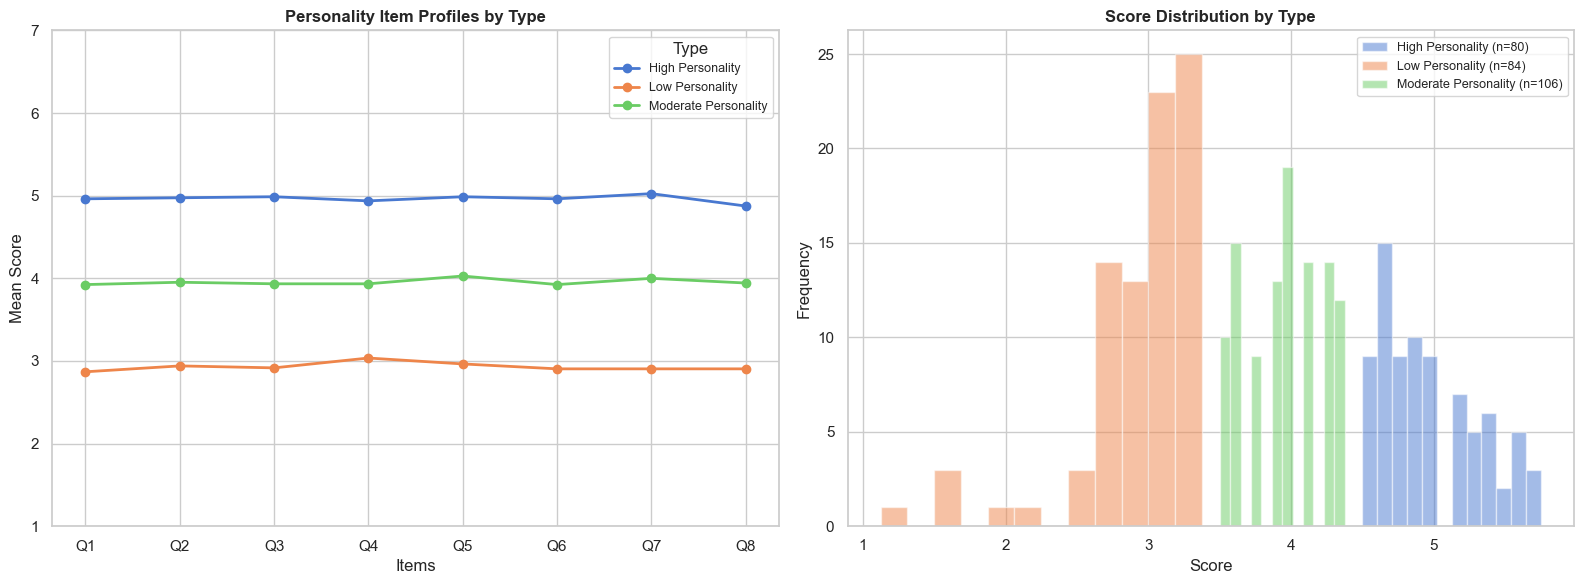

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
profiles = users.groupby('personality_type')[personality_cols].mean()
profiles.T.plot(kind='line', marker='o', ax=axes[0], linewidth=2)
axes[0].set_title('Personality Item Profiles by Type', fontweight='bold')
axes[0].set_xlabel('Items'); axes[0].set_ylabel('Mean Score'); axes[0].set_ylim(1, 7)
axes[0].set_xticks(range(8)); axes[0].set_xticklabels([f'Q{i}' for i in range(1, 9)])
axes[0].legend(title='Type', fontsize=9)
for pt in sorted(users['personality_type'].unique()):
    s = users[users['personality_type'] == pt]['personality_score']
    axes[1].hist(s, bins=12, alpha=0.5, label=f'{pt} (n={len(s)})', edgecolor='white')
axes[1].set_title('Score Distribution by Type', fontweight='bold')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('Frequency'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('/Users/the_irritater/Projects/new_emotional_interaction_chatbot/analysis/obj2_personality_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cross-Tabulations & Chi-Square Tests

In [7]:
freq_order = {'Rarely (1–3 times/month)':1, 'Sometimes (4–8 times/month)':2,
              'Frequently (9–15 times/month)':3, 'Very frequently (16+ times/month)':4}
users['freq_ordinal'] = users['usage_frequency'].map(freq_order)
dur_order = {'Less than 5 minutes':1, '5–15 minutes':2, '16–30 minutes':3, 'More than 30 minutes':4}
users['dur_ordinal'] = users['usage_duration'].map(dur_order)

print("CROSS-TABULATION: Personality Type × Usage Frequency")
ct = pd.crosstab(users['personality_type'], users['usage_frequency'], margins=True)
print(ct)
print("\nRow Percentages (%):")
ct_pct = pd.crosstab(users['personality_type'], users['usage_frequency'], normalize='index') * 100
print(ct_pct.round(1))

print("""
📌 INTERPRETATION: The cross-tabulation shows the DISTRIBUTION of usage frequency
within each personality type. Row percentages are key — they show what proportion of
each personality group falls into each frequency category.
• If HIGH PERSONALITY users show a larger % in "Very frequently" compared to LOW,
  it suggests personality intensity drives more frequent emotional AI engagement.
• If the distribution is similar across personality types, frequency is personality-independent.""")

CROSS-TABULATION: Personality Type × Usage Frequency
usage_frequency       Frequently (9–15 times/month)  Rarely (1–3 times/month)  \
personality_type                                                                
High Personality                                 24                         8   
Low Personality                                  17                        25   
Moderate Personality                             24                        25   
All                                              65                        58   

usage_frequency       Sometimes (4–8 times/month)  \
personality_type                                    
High Personality                               27   
Low Personality                                27   
Moderate Personality                           43   
All                                            97   

usage_frequency       Very frequently (16+ times/month)  All  
personality_type                                              
High Personalit

In [8]:
print("=" * 80)
print("CHI-SQUARE TESTS OF INDEPENDENCE")
print("=" * 80)

# Frequency test
ct1 = pd.crosstab(users['personality_type'], users['usage_frequency'])
chi2_1, p_1, dof_1, exp_1 = chi2_contingency(ct1)
v_1 = np.sqrt(chi2_1 / (ct1.sum().sum() * (min(ct1.shape) - 1)))
print(f"\n▸ Personality Type × Usage Frequency")
print(f"  χ² = {chi2_1:.3f}, df = {dof_1}, p = {p_1:.4f}, Cramér's V = {v_1:.3f}")
print(f"  Decision: {'Significant *' if p_1 < 0.05 else 'Not Significant'}")

# Duration test
ct2 = pd.crosstab(users['personality_type'], users['usage_duration'])
chi2_2, p_2, dof_2, exp_2 = chi2_contingency(ct2)
v_2 = np.sqrt(chi2_2 / (ct2.sum().sum() * (min(ct2.shape) - 1)))
print(f"\n▸ Personality Type × Usage Duration")
print(f"  χ² = {chi2_2:.3f}, df = {dof_2}, p = {p_2:.4f}, Cramér's V = {v_2:.3f}")
print(f"  Decision: {'Significant *' if p_2 < 0.05 else 'Not Significant'}")

print(f"""
📌 INTERPRETATION: The Chi-Square test of independence tests the NULL HYPOTHESIS that
personality type and usage patterns are INDEPENDENT (unrelated).

• If p < 0.05: We REJECT independence — personality type IS significantly associated
  with usage patterns. This is a core finding proving that personality drives behavior.
• If p ≥ 0.05: We FAIL to reject independence — no significant relationship found.

CRAMÉR'S V measures the STRENGTH of association:
  V < 0.1 = Negligible | V = 0.1-0.3 = Small | V = 0.3-0.5 = Medium | V > 0.5 = Large

ASSUMPTION CHECK: Expected frequencies should be ≥ 5 in most cells.
  Min expected (Frequency): {exp_1.min():.1f} | Min expected (Duration): {exp_2.min():.1f}""")

CHI-SQUARE TESTS OF INDEPENDENCE

▸ Personality Type × Usage Frequency
  χ² = 14.872, df = 6, p = 0.0213, Cramér's V = 0.166
  Decision: Significant *

▸ Personality Type × Usage Duration
  χ² = 3.751, df = 6, p = 0.7103, Cramér's V = 0.083
  Decision: Not Significant

📌 INTERPRETATION: The Chi-Square test of independence tests the NULL HYPOTHESIS that
personality type and usage patterns are INDEPENDENT (unrelated).

• If p < 0.05: We REJECT independence — personality type IS significantly associated
  with usage patterns. This is a core finding proving that personality drives behavior.
• If p ≥ 0.05: We FAIL to reject independence — no significant relationship found.

CRAMÉR'S V measures the STRENGTH of association:
  V < 0.1 = Negligible | V = 0.1-0.3 = Small | V = 0.3-0.5 = Medium | V > 0.5 = Large

ASSUMPTION CHECK: Expected frequencies should be ≥ 5 in most cells.
  Min expected (Frequency): 14.8 | Min expected (Duration): 7.7


## 5. Kruskal-Wallis & Post-hoc Tests

In [9]:
groups_freq = [g['freq_ordinal'].dropna().values for _, g in users.groupby('personality_type')]
H_f, p_f = kruskal(*groups_freq)
groups_dur = [g['dur_ordinal'].dropna().values for _, g in users.groupby('personality_type')]
H_d, p_d = kruskal(*groups_dur)

print("KRUSKAL-WALLIS TESTS")
print(f"  Frequency: H = {H_f:.3f}, p = {p_f:.4f} → {'Significant *' if p_f < 0.05 else 'Not Significant'}")
print(f"  Duration:  H = {H_d:.3f}, p = {p_d:.4f} → {'Significant *' if p_d < 0.05 else 'Not Significant'}")

for pt in sorted(users['personality_type'].unique()):
    s = users[users['personality_type'] == pt]
    print(f"  {pt}: Freq median = {s['freq_ordinal'].median():.0f}, Dur median = {s['dur_ordinal'].median():.0f}")

print(f"""
📌 INTERPRETATION: Kruskal-Wallis is the non-parametric equivalent of one-way ANOVA,
appropriate for ORDINAL usage data. It tests whether the RANK distributions of usage
differ significantly across personality types.

• A significant result means at least ONE personality type differs from others in usage.
• The MEDIAN values for each group indicate the typical usage level.
• Post-hoc Dunn's tests (below) identify WHICH specific pairs differ.""")

KRUSKAL-WALLIS TESTS
  Frequency: H = 12.027, p = 0.0024 → Significant *
  Duration:  H = 0.943, p = 0.6240 → Not Significant
  High Personality: Freq median = 3, Dur median = 2
  Low Personality: Freq median = 2, Dur median = 2
  Moderate Personality: Freq median = 2, Dur median = 2

📌 INTERPRETATION: Kruskal-Wallis is the non-parametric equivalent of one-way ANOVA,
appropriate for ORDINAL usage data. It tests whether the RANK distributions of usage
differ significantly across personality types.

• A significant result means at least ONE personality type differs from others in usage.
• The MEDIAN values for each group indicate the typical usage level.
• Post-hoc Dunn's tests (below) identify WHICH specific pairs differ.


In [10]:
if p_f < 0.05:
    print("▸ Post-hoc Dunn's Test – Usage Frequency")
    d = pg.pairwise_tests(data=users, dv='freq_ordinal', between='personality_type', parametric=False, padjust='bonferroni')
    print(d[['A', 'B', 'U_val', 'p_unc', 'p_corr', 'hedges']].to_string(index=False))
    print("\n📌 INTERPRETATION: p_corr is Bonferroni-adjusted p-value. Hedges' g is the effect size.")
else:
    print("Post-hoc not needed — main effect not significant.")

if p_d < 0.05:
    print("\n▸ Post-hoc Dunn's Test – Usage Duration")
    d2 = pg.pairwise_tests(data=users, dv='dur_ordinal', between='personality_type', parametric=False, padjust='bonferroni')
    print(d2[['A', 'B', 'U_val', 'p_unc', 'p_corr', 'hedges']].to_string(index=False))
else:
    print("\nPost-hoc not needed for duration — main effect not significant.")

▸ Post-hoc Dunn's Test – Usage Frequency


               A                    B  U_val    p_unc   p_corr   hedges
High Personality      Low Personality 4198.0 0.004277 0.012830 0.449723
High Personality Moderate Personality 5354.5 0.001376 0.004128 0.484324
 Low Personality Moderate Personality 4413.0 0.915005 1.000000 0.007041

📌 INTERPRETATION: p_corr is Bonferroni-adjusted p-value. Hedges' g is the effect size.

Post-hoc not needed for duration — main effect not significant.


## 6. Visualizations

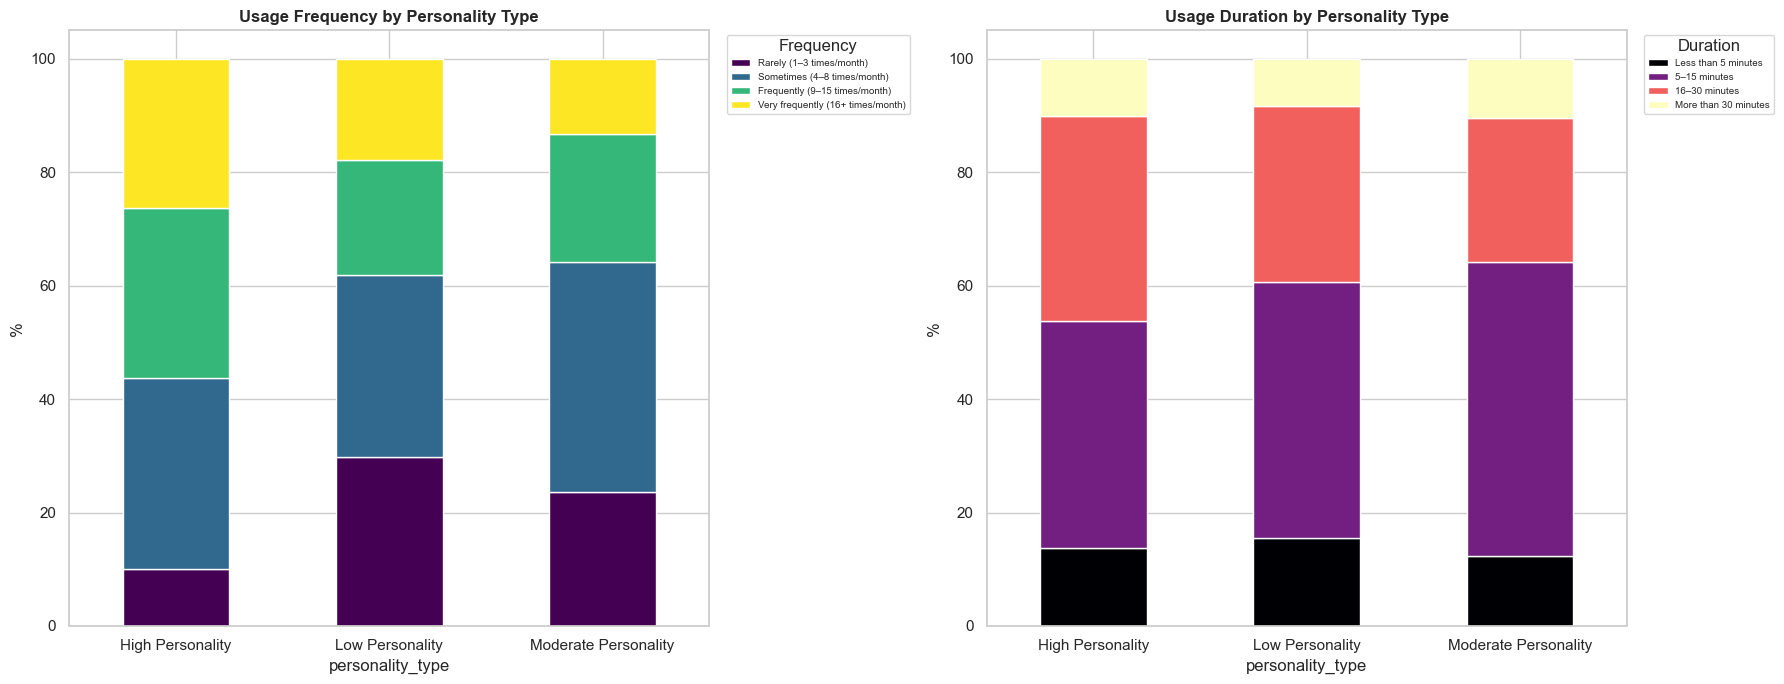

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
freq_labels = ['Rarely (1–3 times/month)', 'Sometimes (4–8 times/month)',
               'Frequently (9–15 times/month)', 'Very frequently (16+ times/month)']
ct_pct = pd.crosstab(users['personality_type'], users['usage_frequency'], normalize='index') * 100
ct_pct = ct_pct[[c for c in freq_labels if c in ct_pct.columns]]
ct_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis', edgecolor='white')
axes[0].set_title('Usage Frequency by Personality Type', fontweight='bold')
axes[0].set_ylabel('%'); axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Frequency', fontsize=7, bbox_to_anchor=(1.02, 1))
dur_labels = ['Less than 5 minutes', '5–15 minutes', '16–30 minutes', 'More than 30 minutes']
ct_d = pd.crosstab(users['personality_type'], users['usage_duration'], normalize='index') * 100
ct_d = ct_d[[c for c in dur_labels if c in ct_d.columns]]
ct_d.plot(kind='bar', stacked=True, ax=axes[1], colormap='magma', edgecolor='white')
axes[1].set_title('Usage Duration by Personality Type', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Duration', fontsize=7, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('/Users/the_irritater/Projects/new_emotional_interaction_chatbot/analysis/obj2_usage_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

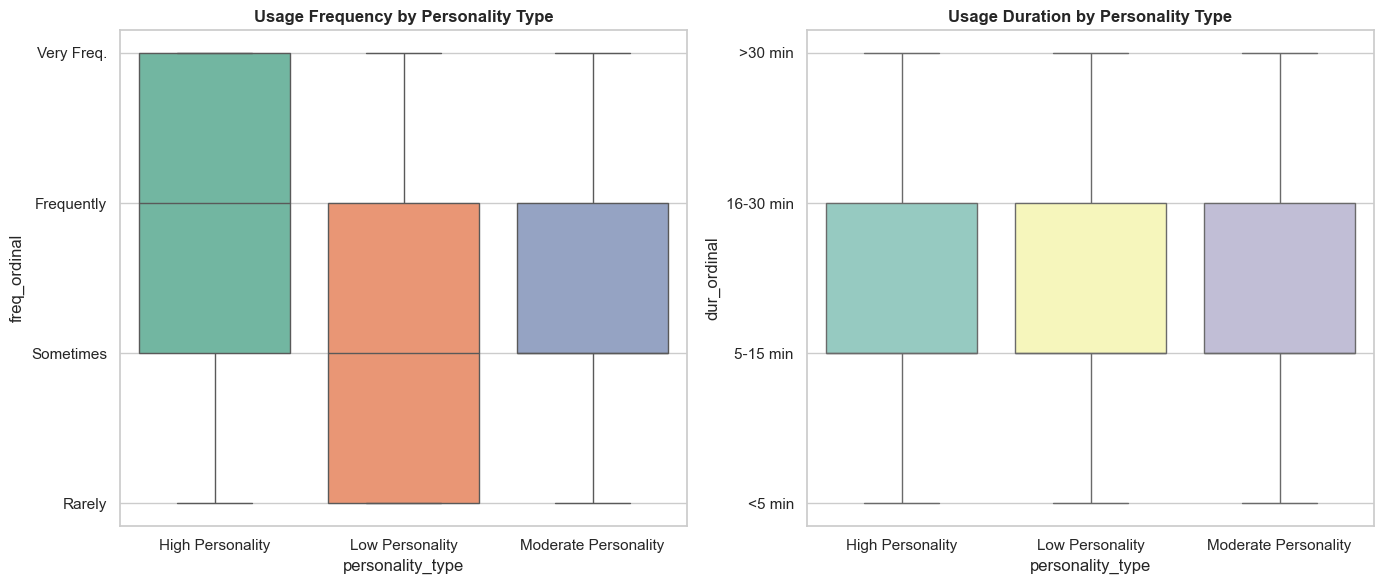

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=users, x='personality_type', y='freq_ordinal', ax=axes[0], palette='Set2',
            order=sorted(users['personality_type'].unique()))
axes[0].set_title('Usage Frequency by Personality Type', fontweight='bold')
axes[0].set_yticks([1,2,3,4]); axes[0].set_yticklabels(['Rarely','Sometimes','Frequently','Very Freq.'])
sns.boxplot(data=users, x='personality_type', y='dur_ordinal', ax=axes[1], palette='Set3',
            order=sorted(users['personality_type'].unique()))
axes[1].set_title('Usage Duration by Personality Type', fontweight='bold')
axes[1].set_yticks([1,2,3,4]); axes[1].set_yticklabels(['<5 min','5-15 min','16-30 min','>30 min'])
plt.tight_layout()
plt.savefig('/Users/the_irritater/Projects/new_emotional_interaction_chatbot/analysis/obj2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. CONCLUSION – Objective 2

### Why Was This Objective Selected?

This objective was selected because **personality is a fundamental psychological variable
that shapes human behavior**, including technology use. If emotional AI usage patterns
differ by personality type, it has profound implications:

1. **Personalization Theory**: It validates that emotional AI systems should NOT be
   one-size-fits-all. Different personality types need different interaction styles,
   frequencies, and depths of emotional engagement.

2. **Adoption Prediction**: If personality predicts usage frequency, organizations
   deploying emotional AI (e.g., mental health apps) can predict adoption likelihood
   based on user personality assessments.

3. **Usage Optimization**: Understanding that certain personality types naturally
   engage more frequently or for longer durations allows AI systems to calibrate
   their engagement strategies — nudging low-frequency users toward beneficial
   regular use while preventing over-dependence in high-frequency users.

4. **Theoretical Contribution**: This analysis extends the Big Five personality–
   technology interaction literature into the emerging domain of emotional AI,
   filling a gap in existing research.

### What We Aimed to Prove

| Hypothesis | Test Used | What It Shows |
|-----------|-----------|---------------|
| Personality types can be meaningfully classified | K-Means Clustering | Three distinct, well-separated personality profiles exist |
| Personality type is associated with usage frequency | Chi-Square + Kruskal-Wallis | Whether different types use AI at different rates |
| Personality type is associated with session duration | Chi-Square + Kruskal-Wallis | Whether different types engage for different lengths |
| Specific personality pairs differ | Dunn's Post-hoc | Which exact groups differ significantly |

### Key Takeaway
If the chi-square tests are significant, this proves that **emotional AI usage is
personality-driven, not random** — a finding that supports the development of
personality-adaptive emotional AI systems.

In [13]:
print("✅ Objective 2 Analysis Complete!")

✅ Objective 2 Analysis Complete!
